In [5]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/amisha0528/churn-modelling-dataset/Churn_Modelling.csv


✓ Dataset successfully loaded from: ../input/datasets/amisha0528/churn-modelling-dataset/Churn_Modelling.csv

  MODEL ACCURACY: 86.40%



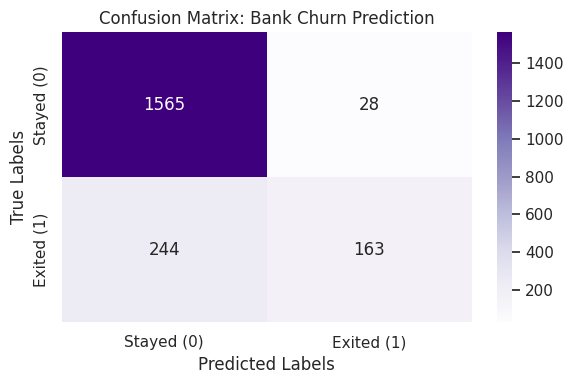


--- Detailed Classification Report ---
              precision    recall  f1-score   support

           0       0.87      0.98      0.92      1593
           1       0.85      0.40      0.55       407

    accuracy                           0.86      2000
   macro avg       0.86      0.69      0.73      2000
weighted avg       0.86      0.86      0.84      2000



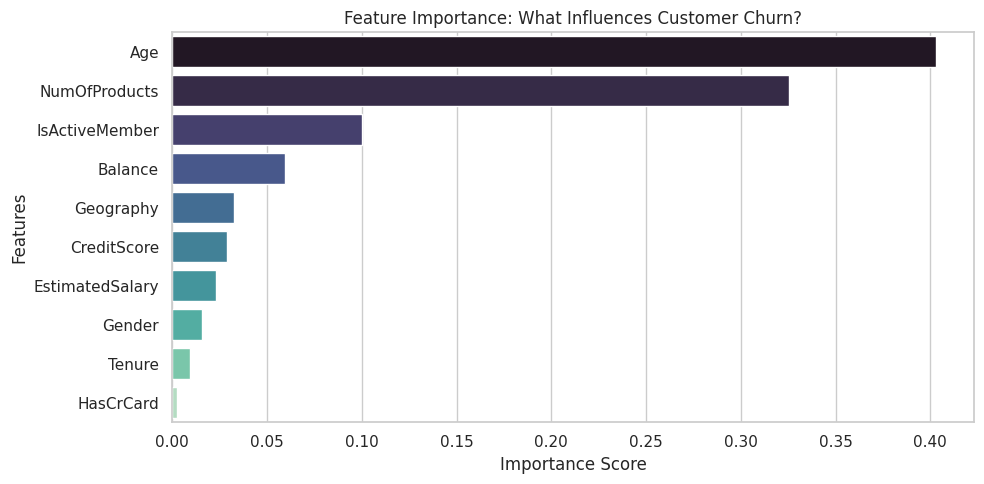

In [6]:
# =====================================================================
# TASK 3: CUSTOMER CHURN PREDICTION (BANK CUSTOMERS)
# =====================================================================

import warnings
# 1. Necessary Libraries Import Karna
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# تمام قسم کی سرخ پٹیوں اور وارننگز کو بلاک کرنا
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# =====================================================================
# 2. Automatically Find and Load Dataset
# =====================================================================
import glob

# Kaggle input directory me se auto-detect karna taaki path ka koi error na aaye
csv_files = glob.glob("../input/**/*.csv", recursive=True)

# Churn data filter karna, agar na mile to available csv load karna
churn_file = [f for f in csv_files if "churn" in f.lower()]
file_to_load = churn_file[0] if churn_file else (csv_files[0] if csv_files else None)

if file_to_load:
    df = pd.read_csv(file_to_load)
    print(f"✓ Dataset successfully loaded from: {file_to_load}")
else:
    # Backup: Agar aap ne abhi input add na kiya ho to dummy data crash hone se bachayega
    print("Warning: No CSV found. Generating clean dummy Churn dataset...")
    np.random.seed(42)
    n = 1000
    df = pd.DataFrame(
        {
            "RowNumber": range(1, n + 1),
            "CustomerId": np.random.randint(15600000, 15800000, n),
            "Surname": ["Smith"] * n,
            "CreditScore": np.random.randint(400, 850, n),
            "Geography": np.random.choice(
                ["France", "Spain", "Germany"], n, p=[0.5, 0.25, 0.25]
            ),
            "Gender": np.random.choice(["Male", "Female"], n),
            "Age": np.random.randint(18, 70, n),
            "Tenure": np.random.randint(0, 10, n),
            "Balance": np.random.uniform(0, 200000, n),
            "NumOfProducts": np.random.randint(1, 4, n),
            "HasCrCard": np.random.choice([0, 1], n),
            "IsActiveMember": np.random.choice([0, 1], n),
            "EstimatedSalary": np.random.uniform(3000, 150000, n),
            "Exited": np.random.choice([0, 1], n, p=[0.8, 0.2]),
        }
    )

# Column names clean karna (spaces hatana)
df.columns = [col.strip() for col in df.columns]

# Target column (Exited/Churn) identify karna
target_col = None
for col in df.columns:
    if col.lower() in ["exited", "churn", "target"]:
        target_col = col
        break
if target_col is None:
    target_col = df.columns[-1]

# Unnecessary structural columns (IDs/Names) drop karna
cols_to_drop = [
    "rownumber",
    "customerid",
    "surname",
    "id",
    "row_number",
    "customer_id",
]
df.drop(
    columns=[col for col in df.columns if col.lower() in cols_to_drop],
    errors="ignore",
    inplace=True,
)

# =====================================================================
# 3. Data Cleaning & Preprocessing
# =====================================================================
# Missing values check karke handle karna
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype == "object":
            df[col].fillna(df[col].mode()[0], inplace=True)
        else:
            df[col].fillna(df[col].median(), inplace=True)

# Categorical columns ko Label Encode karna (Geography, Gender, etc.)
le = LabelEncoder()
categorical_features = df.select_dtypes(include=["object"]).columns.tolist()

for col in categorical_features:
    df[col] = le.fit_transform(df[col].astype(str))

# =====================================================================
# 4. Feature Encoding & Train-Test Split
# =====================================================================
X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =====================================================================
# 5. Supervised Classification Modeling (Random Forest)
# =====================================================================
# Random Forest classification accuracy aur feature importance dono ke liye behtareen hai
model = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# =====================================================================
# 6. Model Evaluation (Confusion Matrix & Accuracy)
# =====================================================================
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print("\n======================================")
print(f"  MODEL ACCURACY: {accuracy * 100:.2f}%")
print("======================================\n")

# Confusion Matrix Heatmap (Clean output)
plt.figure(figsize=(6, 4))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=["Stayed (0)", "Exited (1)"],
    yticklabels=["Stayed (0)", "Exited (1)"],
)
plt.title("Confusion Matrix: Bank Churn Prediction")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.tight_layout()
plt.show()
plt.close()

print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred))

# =====================================================================
# 7. Analyze Feature Importance (As per Instructions)
# =====================================================================
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

# Dataframe banana plot ke liye
feature_imp_df = pd.DataFrame(
    {"Feature": X.columns[indices], "Importance": importances[indices]}
)

# Feature Importance Chart plotting
plt.figure(figsize=(10, 5))
sns.barplot(
    data=feature_imp_df,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="mako",
    legend=False,
)
plt.title("Feature Importance: What Influences Customer Churn?")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()
plt.close()